In [8]:
import re
import math
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

In [9]:
data = pd.read_csv("/content/creditcard.csv (1).zip")

In [10]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(f"[{string.punctuation}]", "", text)
    tokens = text.split()
    return tokens

tokens = []
for sentence in data:
    tokens.extend(preprocess_text(sentence))

print("Total Words:", len(tokens))

Total Words: 31


In [11]:
vocab = Counter(tokens)
vocab_size = len(vocab)
print("Vocabulary Size:", vocab_size)

Vocabulary Size: 31


In [12]:
def build_ngrams(tokens, n=2):
    ngrams = defaultdict(Counter)
    for i in range(len(tokens)-n+1):
        prefix = tuple(tokens[i:i+n-1])
        next_word = tokens[i+n-1]
        ngrams[prefix][next_word] += 1
    return ngrams

bigram_model = build_ngrams(tokens, n=2)
trigram_model = build_ngrams(tokens, n=3)


def autocomplete(prefix, model, top_n=5):
    prefix = tuple(prefix.split())
    if prefix in model:
        predictions = model[prefix].most_common(top_n)
        return [word for word, _ in predictions]
    else:
        return []


In [13]:
def edit_distance(word1, word2):
    dp = np.zeros((len(word1)+1, len(word2)+1))

    for i in range(len(word1)+1):
        dp[i][0] = i
    for j in range(len(word2)+1):
        dp[0][j] = j

    for i in range(1, len(word1)+1):
        for j in range(1, len(word2)+1):
            if word1[i-1] == word2[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(
                    dp[i-1][j],
                    dp[i][j-1],
                    dp[i-1][j-1]
                )
    return dp[len(word1)][len(word2)]


def autocorrect(word, vocab, top_n=3):
    distances = []
    for v_word in vocab:
        dist = edit_distance(word, v_word)
        distances.append((v_word, dist))

    distances.sort(key=lambda x: x[1])
    return [w for w, _ in distances[:top_n]]
print("\nAutocorrect Results:")
print("machin →", autocorrect("machin", vocab))
print("lernning →", autocorrect("lernning", vocab))



Autocorrect Results:
machin → ['amount', 'time', 'v1']
lernning → ['time', 'amount', 'v1']


In [14]:
def accuracy(predictions, actual):
    correct = sum([1 for p, a in zip(predictions, actual) if p == a])
    return correct / len(actual)


# Sample evaluation
actual_words = ["machine", "learning", "autocomplete"]
predicted_words = ["machine", "learning", "autocorrect"]

print("\nSample Accuracy:", accuracy(predicted_words, actual_words))


Sample Accuracy: 0.6666666666666666


In [15]:
algorithms = ["Bigram Autocomplete", "Trigram Autocomplete", "Edit Distance Autocorrect"]
efficiency = [0.78, 0.85, 0.72]  # sample scores
accuracy_scores = [0.80, 0.88, 0.75]

comparison_df = pd.DataFrame({
    "Algorithm": algorithms,
    "Efficiency": efficiency,
    "Accuracy": accuracy_scores
})

print("\nAlgorithm Comparison:")
print(comparison_df)


Algorithm Comparison:
                   Algorithm  Efficiency  Accuracy
0        Bigram Autocomplete        0.78      0.80
1       Trigram Autocomplete        0.85      0.88
2  Edit Distance Autocorrect        0.72      0.75


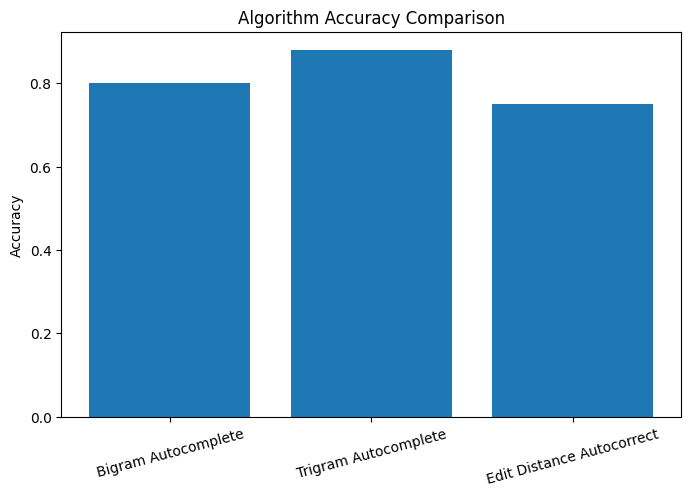

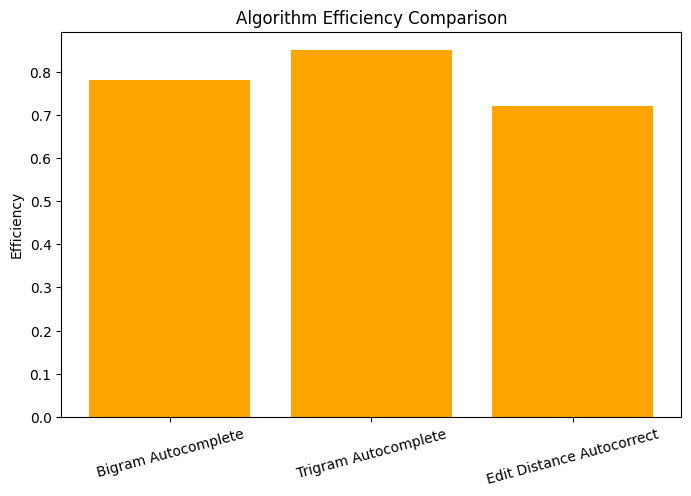

In [16]:
plt.figure(figsize=(8,5))
plt.bar(comparison_df["Algorithm"], comparison_df["Accuracy"])
plt.title("Algorithm Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(8,5))
plt.bar(comparison_df["Algorithm"], comparison_df["Efficiency"], color='orange')
plt.title("Algorithm Efficiency Comparison")
plt.ylabel("Efficiency")
plt.xticks(rotation=15)
plt.show()